In [1]:
from tensorflow import keras

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [4]:
def visualize_input(img, ax):
    ax.imshow(img, cmap='gray')
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y],2)), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y]<thresh else 'black')

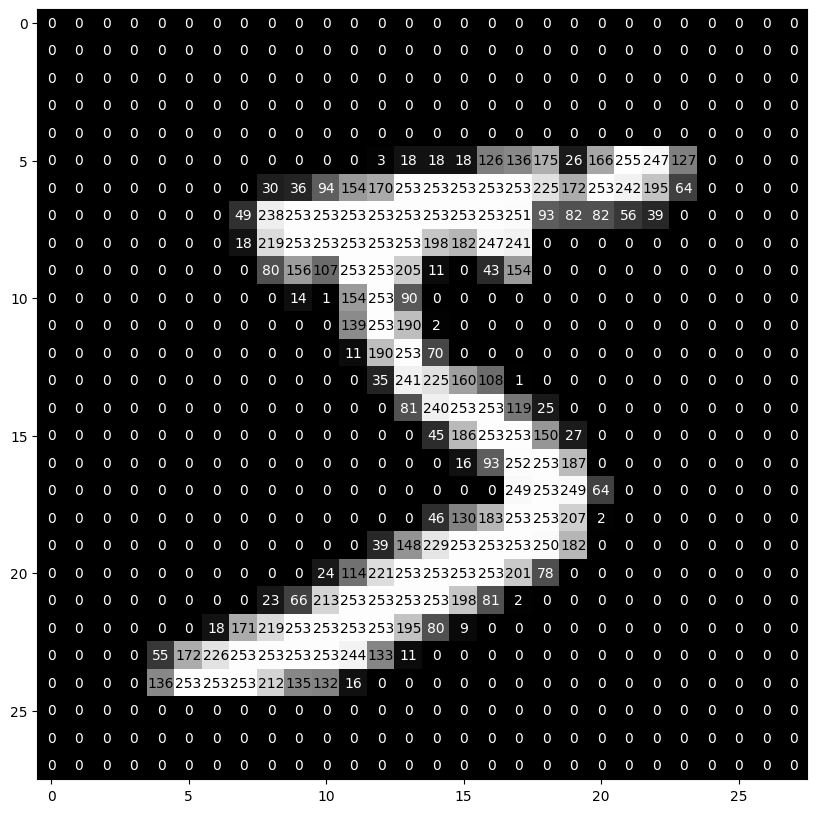

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(111)
visualize_input(x_train[0], ax)
plt.show()

In [6]:
print(y_train)
print(y_test)

[5 0 4 ... 5 6 8]
[7 2 1 ... 4 5 6]


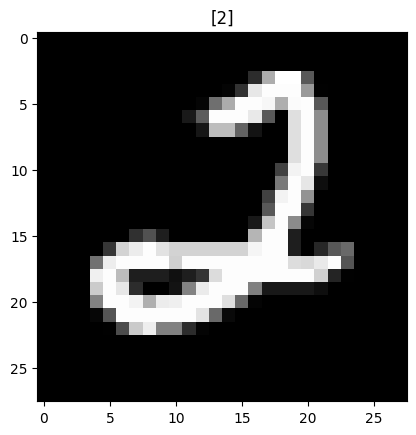

In [7]:
# lets see some random images and its labels
import random
import matplotlib.pyplot as plt
i = random.randint(0,60000)
plt.imshow(x_train[i],cmap='gray') # Color map
plt.title([y_train[i]])
plt.show()

In [8]:
# How many images are there in every digit?
import numpy as np
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [9]:
np.unique(y_test,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))

In [10]:
# Normalization : Scaling down the value to a specific range(0-1)
x_train=x_train/255
x_test = x_test/255

In [11]:
# AFter Normalization
print(x_train.max())
print(x_train.min())

1.0
0.0


In [12]:
from keras.layers import Dense
from keras.layers import Flatten
model = keras.models.Sequential()
model.add(Flatten(input_shape=(28,28))) # 784
model.add(Dense(392,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [14]:
history = model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8873 - loss: 0.3837 - val_accuracy: 0.9638 - val_loss: 0.1218
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9696 - loss: 0.0976 - val_accuracy: 0.9714 - val_loss: 0.1004
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9823 - loss: 0.0581 - val_accuracy: 0.9767 - val_loss: 0.0838
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9872 - loss: 0.0388 - val_accuracy: 0.9748 - val_loss: 0.0907
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9907 - loss: 0.0284 - val_accuracy: 0.9778 - val_loss: 0.0837
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9934 - loss: 0.0207 - val_accuracy: 0.9744 - val_loss: 0.0922
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accuracy: 0.9781 - val_loss: 0.0885
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9966 - loss: 0.0115 - 

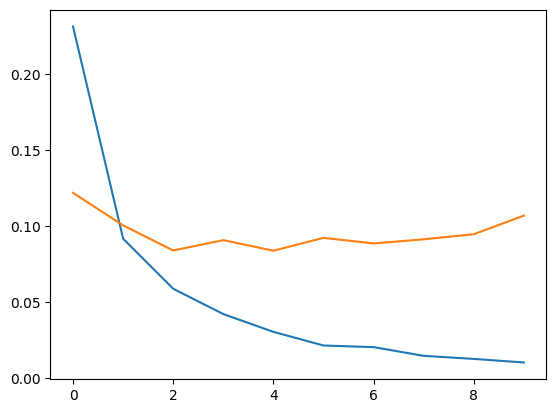

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

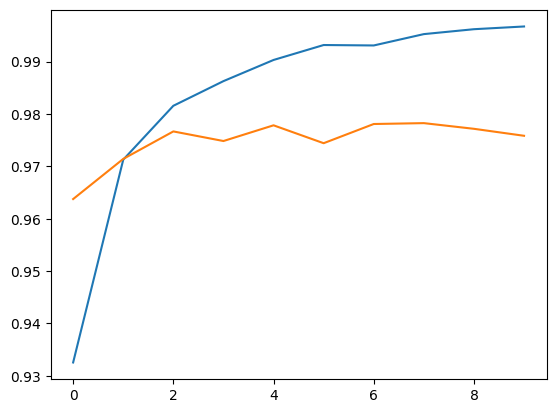

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [17]:
# Evaluate on test data

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred,axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [22]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [23]:
accuracy_score(y_pred,y_test)

0.9764

In [24]:
confusion_matrix(y_pred,y_test)

array([[ 972,    0,    1,    3,    0,    2,    3,    3,    5,    1],
       [   1, 1126,    2,    0,    2,    0,    3,    8,    0,    2],
       [   0,    2, 1004,    0,    3,    0,    2,    5,    2,    0],
       [   1,    3,    8,  992,    2,   10,    1,    5,    6,    3],
       [   1,    0,    2,    0,  936,    0,    3,    2,    1,    4],
       [   1,    1,    0,    3,    0,  871,    9,    0,    6,    4],
       [   0,    2,    2,    0,    4,    1,  933,    0,    0,    0],
       [   1,    1,    4,    3,    2,    1,    1,  993,    4,    1],
       [   2,    0,    8,    3,    5,    6,    2,    5,  947,    4],
       [   1,    0,    1,    6,   28,    1,    1,    7,    3,  990]])

In [25]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       990
           1       0.99      0.98      0.99      1144
           2       0.97      0.99      0.98      1018
           3       0.98      0.96      0.97      1031
           4       0.95      0.99      0.97       949
           5       0.98      0.97      0.97       895
           6       0.97      0.99      0.98       942
           7       0.97      0.98      0.97      1011
           8       0.97      0.96      0.97       982
           9       0.98      0.95      0.97      1038

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [26]:
model.save("mnist.keras")